# Advance Feature Analysis (V2)

Loading the first 3 user JSON files from the raw dataset to start exploring more advanced features.

In [5]:
import json
import os

# Define the path to the raw JSON directory relative to this notebook
raw_data_path = r'../data_raw/feature_kmt_dataset_Edge_Hill_University_22/feature_kmt_json'

# List of 3 files to load
files_to_load = [
    'raw_kmt_user_0001.json',
    'raw_kmt_user_0002.json',
    'raw_kmt_user_0003.json'
]

# Dictionary to hold the loaded JSON data
users_data = {}

# Load each file
for file_name in files_to_load:
    file_path = os.path.join(raw_data_path, file_name)
    with open(file_path, 'r') as f:
        data = json.load(f)
        users_data[file_name] = data
        print(f"Loaded {file_name} successfully. Primary keys: {list(data.keys())}")


Loaded raw_kmt_user_0001.json successfully. Primary keys: ['details', 'true_data', 'false_data']
Loaded raw_kmt_user_0002.json successfully. Primary keys: ['details', 'true_data', 'false_data']
Loaded raw_kmt_user_0003.json successfully. Primary keys: ['details', 'true_data', 'false_data']


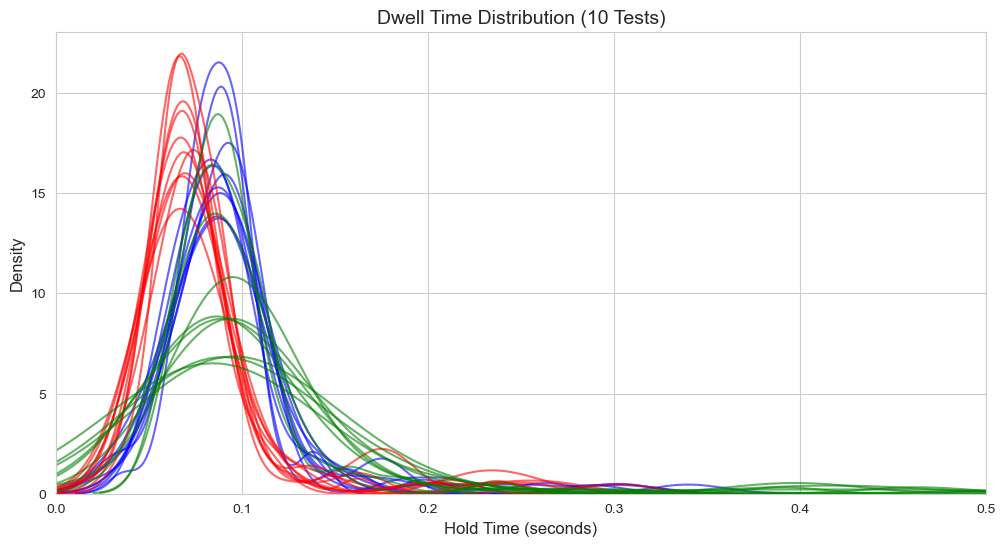

In [6]:
import json
import seaborn as sns
import matplotlib.pyplot as plt


true_data_user_01 = users_data['raw_kmt_user_0001.json']['true_data']
true_data_user_02 = users_data['raw_kmt_user_0002.json']['true_data']
true_data_user_03 = users_data['raw_kmt_user_0003.json']['true_data']

# 2. Function to calculate Dwell Time (Hold Time)
def calculate_dwell_times(events):
    last_press = {}
    dwell_times = []
    for event in events:
        key = event.get('Key')
        event_type = event.get('Event')
        try:
            epoch = float(event.get('Epoch'))
        except (ValueError, TypeError):
            continue
            
        if event_type == 'pressed':
            last_press[key] = epoch
        elif event_type == 'released':
            if key in last_press:
                # Dwell Time = T_release - T_press
                dwell_times.append(epoch - last_press[key])
                del last_press[key]
    return dwell_times

# 3. Setup the Plot
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# 4. Process and Plot each test as a line
# Using a consistent color for all 10 lines
line_color_user_01 = 'blue' 

for test_id in sorted(true_data_user_01.keys()):
    events = true_data_user_01[test_id].get('key_events', [])
    dwell_times = calculate_dwell_times(events)
    
    # Only plot if we have enough data points for a smooth line
    if len(dwell_times) > 1:
        sns.kdeplot(dwell_times, color=line_color_user_01, alpha=0.6, linewidth=1.5, label=test_id)

line_color_user_02 = 'red' 

for test_id in sorted(true_data_user_02.keys()):
    events = true_data_user_02[test_id].get('key_events', [])
    dwell_times = calculate_dwell_times(events)
    
    # Only plot if we have enough data points for a smooth line
    if len(dwell_times) > 1:
        sns.kdeplot(dwell_times, color=line_color_user_02, alpha=0.6, linewidth=1.5, label=test_id)


line_color_user_03 = 'green' 

for test_id in sorted(true_data_user_03.keys()):
    events = true_data_user_03[test_id].get('key_events', [])
    dwell_times = calculate_dwell_times(events)
    
    # Only plot if we have enough data points for a smooth line
    if len(dwell_times) > 1:
        sns.kdeplot(dwell_times, color=line_color_user_03, alpha=0.6, linewidth=1.5, label=test_id)


# 5. Final Formatting
plt.title('Dwell Time Distribution (10 Tests)', fontsize=14)
plt.xlabel('Hold Time (seconds)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xlim(0, 0.5) # Adjust this limit based on your data range
plt.show()

In [7]:
from sympy.parsing.sympy_parser import null
import numpy as np
from scipy import stats
from IPython.display import display
import pandas as pd

def extract_biometric_features(dwell_times):
    data = np.array(dwell_times)
    
    # 1. IQR Filtering to remove outliers
    if len(data) > 4:  # Need sufficient data to calculate quartiles meaningfully
        q1, q3 = np.percentile(data, [25, 75])
        iqr = q3 - q1
        lower_bound = q1 - (1.5 * iqr)
        upper_bound = q3 + (1.5 * iqr)
        
        # Keep only data within the "reasonable" human range
        # Also ensure we don't allow negative dwell times
        cleaned_data = data[(data >= max(0, lower_bound)) & (data <= upper_bound)]
    else:
        cleaned_data = data # Not enough data to filter, proceed as is

    # Fallback if cleaning leaves us with no data
    if len(cleaned_data) == 0:
        return {
            "mean": np.nan, "std": np.nan, "skew": np.nan,
            "kurtosis": np.nan, "gamma_shape": np.nan, "gamma_scale": np.nan
        }

    # 2. Calculate Stats on CLEANED data
    mean_val = np.mean(cleaned_data)
    std_dev = np.std(cleaned_data)
    skewness = stats.skew(cleaned_data)
    kurtosis = stats.kurtosis(cleaned_data)
    
    # 3. Parametric Fitting (Gamma) on CLEANED data
    try:
        # Fitting on cleaned data will produce much more stable shape/scale values
        shape, loc, scale = stats.gamma.fit(cleaned_data, floc=0) 
    except:
        shape, loc, scale = np.nan, np.nan, np.nan
        
    return {
        "mean": mean_val,
        "std": std_dev,
        "skew": skewness,
        "kurtosis": kurtosis,
        "gamma_shape": shape,
        "gamma_scale": scale
    }

# Create an empty list to store the features for all tests
all_test_features = []

# Loop through tests 1 to 10
for i in range(1, 11):
    test_key = f'test_{i}' # Formats as 'test_1', 'test_2', ..., 'test_10'
    
    # Check if the test key exists in the user's data
    if test_key in true_data_user_01:
        events = true_data_user_01[test_key].get('key_events', [])
        
        # Calculate dwell times (assuming calculate_dwell_times is defined earlier in your notebook)
        dwell_times = calculate_dwell_times(events)
        
        # Extract features
        features = extract_biometric_features(dwell_times)
        
        # Add the test name to the dictionary so we can identify it in the DataFrame
        features['test_id'] = test_key
        
        # Append to our list
        all_test_features.append(features)
    else:
        print(f"Warning: {test_key} not found in the data.")

# Convert the list of all test features into a single pandas DataFrame
df_features = pd.DataFrame(all_test_features)

# Move 'test_id' to be the first column for better readability
if not df_features.empty:
    cols = ['test_id'] + [col for col in df_features.columns if col != 'test_id']
    df_features = df_features[cols]

# Display the final DataFrame containing all tests
display(df_features)


,test_id,mean,std,skew,kurtosis,gamma_shape,gamma_scale
0,test_1,0.086414,0.016220,-0.049620,-0.940319,27.332493,0.003162
1,test_2,0.085432,0.013853,-0.231369,-0.665543,36.094959,0.002367
2,test_3,0.087346,0.017016,-0.272503,-0.387325,24.226644,0.003605
3,test_4,0.087753,0.015966,-0.524898,-0.538410,27.260723,0.003219
4,test_5,0.082297,0.017404,0.189877,-0.367492,21.852163,0.003766
5,test_6,0.083867,0.014898,-0.066401,-0.471046,30.292108,0.002769
6,test_7,0.086171,0.013198,-0.093089,-0.785274,41.259803,0.002088
7,test_8,0.086997,0.014895,-0.242027,-0.177354,31.846139,0.002732
8,test_9,0.085313,0.016768,-0.158629,-0.063723,24.042699,0.003548
9,test_10,0.087589,0.015151,-0.165292,0.121525,31.304305,0.002798
